<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 146 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Deep Learning Primer &middot; Challenge Solutions</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Worked solutions: a neuron by hand, the linear baseline, training the network, the no-nonlinearity ablation, and the decision-boundary plot.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch, torch.nn as nn
np.random.seed(46); torch.manual_seed(46)
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR, RD = "#a21caf", "#2563eb", "#16a34a", "#dc2626"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "deep-learning-primer--sensor-qc.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape); print(df.head())
X = df[["sensor_a","sensor_b"]].values; y = df["passed_qc"].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
Xtr_t = torch.tensor(Xtr, dtype=torch.float32); ytr_t = torch.tensor(ytr, dtype=torch.float32).unsqueeze(1)
Xte_t = torch.tensor(Xte, dtype=torch.float32); yte_t = torch.tensor(yte, dtype=torch.float32).unsqueeze(1)

(1200, 3)
   sensor_a  sensor_b  passed_qc
0     2.434    -0.347          0
1    -2.537    -2.739          0
2    -1.365     2.489          0
3     0.731     1.895          1
4     2.604    -0.033          0


## Challenge 1 &middot; Neuron by hand
One neuron = weighted sum + bias, then a sigmoid.

In [2]:
w = np.array([0.7, -0.4]); b = 0.1; x = np.array([1.5, 2.0])
print(f"output = {1/(1+np.exp(-(w@x+b))):.3f}")

output = 0.587


## Challenge 2 &middot; Linear baseline
A straight line cannot enclose a ring, so logistic regression stalls near 60%.

In [3]:
lr = LogisticRegression().fit(Xtr, ytr)
print(f"logistic regression accuracy = {accuracy_score(yte, lr.predict(Xte)):.3f}")

logistic regression accuracy = 0.614


## Challenge 3 &middot; Train the network
Forward, loss, backward, step, repeat.

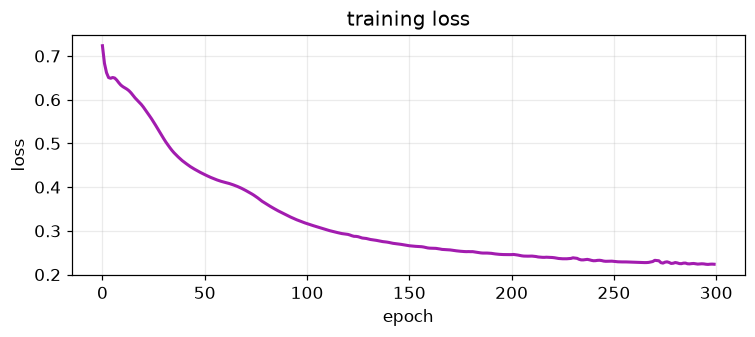

MLP accuracy = 0.911


In [4]:
def train(model, epochs=300, lr=0.02):
    opt = torch.optim.Adam(model.parameters(), lr=lr); lf = nn.BCEWithLogitsLoss(); L=[]
    for _ in range(epochs):
        opt.zero_grad(); loss = lf(model(Xtr_t), ytr_t); loss.backward(); opt.step(); L.append(loss.item())
    return L
torch.manual_seed(46)
mlp = nn.Sequential(nn.Linear(2,16), nn.ReLU(), nn.Linear(16,16), nn.ReLU(), nn.Linear(16,1))
L = train(mlp)
plt.figure(figsize=(7,3.2)); plt.plot(L, color=FU, lw=2); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("training loss"); plt.tight_layout(); plt.show()
with torch.no_grad():
    print(f"MLP accuracy = {((torch.sigmoid(mlp(Xte_t))>0.5).float()==yte_t).float().mean().item():.3f}")

## Challenge 4 &middot; Remove the nonlinearity
Delete the ReLUs: stacked linear layers are still ONE linear map, so accuracy collapses back to the linear level.

In [5]:
torch.manual_seed(46)
linear_only = nn.Sequential(nn.Linear(2,16), nn.Linear(16,16), nn.Linear(16,1))  # no ReLU
train(linear_only)
with torch.no_grad():
    print(f"linear-only network accuracy = {((torch.sigmoid(linear_only(Xte_t))>0.5).float()==yte_t).float().mean().item():.3f}")
print("Same as logistic regression: without a nonlinearity, depth adds nothing.")

linear-only network accuracy = 0.614
Same as logistic regression: without a nonlinearity, depth adds nothing.


## Challenge 5 &middot; Draw the boundary
Predict over a grid and contour the 0.5 line: the trained network traces the ring.

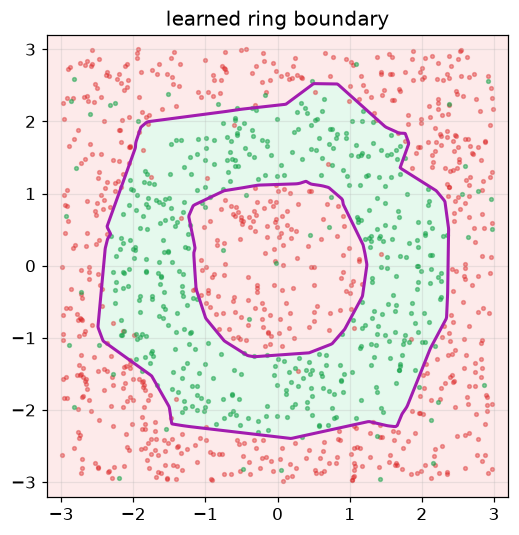

In [6]:
gx, gy = np.meshgrid(np.linspace(-3.2,3.2,300), np.linspace(-3.2,3.2,300))
grid = torch.tensor(np.c_[gx.ravel(), gy.ravel()], dtype=torch.float32)
with torch.no_grad(): zz = torch.sigmoid(mlp(grid)).numpy().reshape(gx.shape)
plt.figure(figsize=(5.2,5))
plt.contourf(gx, gy, zz, levels=[0,0.5,1], colors=["#fde8e8","#e3f9ec"], alpha=0.9)
plt.contour(gx, gy, zz, levels=[0.5], colors=[FU], linewidths=2)
plt.scatter(X[y==0,0], X[y==0,1], s=6, color=RD, alpha=0.4); plt.scatter(X[y==1,0], X[y==1,1], s=6, color=GR, alpha=0.5)
plt.gca().set_aspect("equal"); plt.title("learned ring boundary"); plt.tight_layout(); plt.show()